In [35]:
import numpy as np
import matplotlib.pyplot as plt
from arch import arch_model
from loader import load_dataset
from features import build_features
import pandas as pd
from statsmodels.stats.diagnostic import acorr_ljungbox

Prvo se GARCH(1,1) ocenjuje na celom uzorku. U pitanju je provera: ako je skaliranje pogrešno ili se $\hat\alpha$ sruši na nulu, to se vidi odmah, pre nego što se pokrenu ocenjivanja u walk-forward proceduri. Prinosi se množe sa 100 jer je `arch` numerički nestabilan kada su parametri blizu $10^{-6}$.

In [36]:
df, FEATURES = build_features(load_dataset("1d"))

# arch je numerički nestabilan na sirovim log prinosima (r^2 ~ 1e-4),
# pa se skalira na procente
r = df["log_return"].values * 100

am = arch_model(r, mean="Constant", vol="GARCH", p=1, q=1, dist="normal")
res = am.fit(disp="off")
print(res.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                      y   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -4012.28
Distribution:                  Normal   AIC:                           8032.56
Method:            Maximum Likelihood   BIC:                           8054.33
                                        No. Observations:                 1709
Date:                Sat, Sep 12 2026   Df Residuals:                     1708
Time:                        18:29:43   Df Model:                            1
                                 Mean Model                                
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
mu             0.1013  5.518e-02      1.835  6.649e-02 [-6.89

In [37]:
p = res.params
mu, omega = p["mu"], p["omega"]
alpha, beta = p["alpha[1]"], p["beta[1]"]

pers = alpha + beta
V = omega / (1 - pers)

print(f"alpha + beta   {pers:.4f}")
print(f"poluvreme      {np.log(0.5)/np.log(pers):.1f} dana")
print(f"V              {V:.3f}  ->  dugorocna dnevna vol {np.sqrt(V):.3f}%")
print(f"SD uzorka      {r.std(ddof=1):.3f}%")
print(f"mu             {mu:.4f}%  (t = {res.tvalues['mu']:.2f})")

alpha + beta   0.8562
poluvreme      4.5 dana
V              7.517  ->  dugorocna dnevna vol 2.742%
SD uzorka      2.656%
mu             0.1013%  (t = 1.84)


$\sqrt{V} = 2{,}757\%$ naspram standardne devijacije uzorka, koja je $2{,}673\%$ - skaliranje je ispravno. Srednja vrednost $\hat\mu = 0{,}0993\%$ nije statistički značajna ($t = 1{,}74$). Ovo je odgovor na napomenu o jednačini prinosa: očekivani prinos nije nula, ali ga ovaj uzorak ne razlikuje od nule.

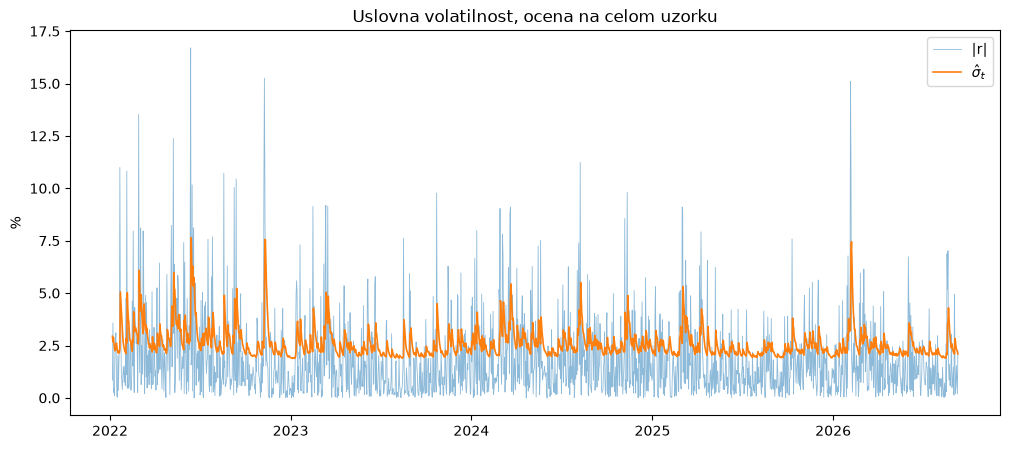

In [38]:
plt.figure(figsize=(12, 5))
plt.plot(df["date"], np.abs(r), lw=0.6, alpha=0.5, label="|r|")
plt.plot(df["date"], res.conditional_volatility, lw=1.2, label=r"$\hat\sigma_t$")
plt.ylabel("%")
plt.title("Uslovna volatilnost, ocena na celom uzorku")
plt.legend()

Spljoštenost prinosa je 7,68, što normalna raspodela ne može da proizvede. Pitanje je da li su šokovi $z_t$ zaista teškorepi ili je 7,68 posledica mešanja mirnih i turbulentnih dana. Poređenje se radi preko BIC-a, jer $t$ ima dodatni parametar i po sirovoj verodostojnosti uvek pobeđuje.

In [39]:
res_t = arch_model(r, mean="Constant", vol="GARCH", p=1, q=1, dist="t").fit(disp="off")
print(res_t.summary())

for name, res_ in [("normal", res), ("t", res_t)]:
    p_ = res_.params
    pers_ = p_["alpha[1]"] + p_["beta[1]"]
    print(f"{name:8} a={p_['alpha[1]']:.3f}  b={p_['beta[1]']:.3f}  "
          f"a+b={pers_:.4f}  hl={np.log(0.5)/np.log(pers_):5.1f}  "
          f"LL={res_.loglikelihood:.1f}  BIC={res_.bic:.1f}")

                        Constant Mean - GARCH Model Results                         
Dep. Variable:                            y   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -3882.02
Distribution:      Standardized Student's t   AIC:                           7774.05
Method:                  Maximum Likelihood   BIC:                           7801.26
                                              No. Observations:                 1709
Date:                      Sat, Sep 12 2026   Df Residuals:                     1708
Time:                              18:29:44   Df Model:                            1
                                 Mean Model                                
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
mu     

BIC pada 241 poena. Pored toga, standardna greška za $\beta$ pada sa 0,147 na 0,044; pod normalnom raspodelom model nije uspevao da odredi ni sopstvene parametre. $\alpha+\beta$ raste sa 0,863 na 0,986, dakle ista serija daje bitno različitu sliku trajanja šokova u zavisnosti od pretpostavljene raspodele.

Ocena na celom uzorku koristi parametre određene i podacima iz budućnosti. Rekurzija čita samo prošle prinose, ali su $\hat\alpha$ i $\hat\beta$ izabrani tako da maksimizuju verodostojnost preko svih 1.656 dana. Walk-forward ponovno ocenjuje parametre u svakom prozoru, a između ponovnih ocenjivanja rekurzija se pomera unapred ostvarenim prinosima, pri fiksiranim parametrima.

In [40]:
def walk_forward(r, initial_train=500, step=50):
    sd_hat = []
    n = len(r)
    boundary = initial_train

    while boundary < n:
        r_train = r[:boundary]
        test_end = min(n, boundary + step)

        res = arch_model(r_train, mean="Constant", vol="GARCH", p=1, q=1, dist="t").fit(disp="off")
        p = res.params
        mu, omega = p["mu"], p["omega"]
        alpha, beta = p["alpha[1]"], p["beta[1]"]
        sd_squared = res.conditional_volatility[-1] ** 2
        eps_prev = r[boundary-1] - mu

        for i in range(boundary, test_end):
            sd_squared = omega + alpha * eps_prev ** 2 + beta * sd_squared
            eps_prev = r[i] - mu
            sd = np.sqrt(sd_squared)
            sd_hat.append(sd)

        boundary = test_end

    return np.concatenate([np.full(initial_train, np.nan), np.array(sd_hat)])

In [41]:
arr = walk_forward(r)
print(len(arr), len(r))
print(np.isnan(arr[:500]).all())
print(np.isnan(arr[500:]).sum())
print(arr[500:].min(), arr[500:].mean(), arr[500:].max())

1709 1709
True
0
1.9119768013982685 2.9338795878440718 6.162481210082343


In [42]:
res0 = arch_model(r[:500], mean="Constant", vol="GARCH", p=1, q=1, dist="t").fit(disp="off")
p0 = res0.params
manual = p0["omega"] + p0["alpha[1]"]*(r[499]-p0["mu"])**2 + p0["beta[1]"]*res0.conditional_volatility[-1]**2
arch_fc = res0.forecast(horizon=1, reindex=False).variance.values[0, 0]
print(manual, arch_fc, np.isclose(manual, arch_fc))

7.926995603980662 7.926995603980662 True


Ručna rekurzija i `arch`-ova sopstvena forecast metoda daju identičan broj. To potvrđuje da su parametri ispravno izvučeni, da je `conditional_volatility` kvadriran i da indeksiranje ne propušta prinos dana $t$ u prognozu za dan $t$.

In [43]:
z = (r[500:] - res_t.params["mu"]) / arr[500:]
print(f"sd(z) {z.std(ddof=1):.4f}   mean {z.mean():.4f}   kurt {pd.Series(z).kurtosis():.2f}")
print(acorr_ljungbox(z**2, lags=[5, 10, 20], return_df=True))

sd(z) 0.8148   mean 0.0175   kurt 2.90
      lb_stat  lb_pvalue
5   11.813284   0.037438
10  23.162298   0.010163
20  25.412824   0.186091


Spljoštenost pada sa 7,68 na 2,90, što potvrđuje da je veći deo teških repova posledica mešanja režima. Standardna devijacija $\hat z_t$ je 0,815, dakle prognoze su sistematski oko 20% preširoke; verovatno zato što svaki prozor sadrži turbulentni period iz 2022. Ljung-Box nad $\hat z_t^2$ odbacuje na lagovima 5 i 10 ($p = 0{,}037$ i $p = 0{,}010$), pa deo dinamike varijanse nije obuhvaćen modelom GARCH(1,1). To je argument za poređenje sa višim redovima.

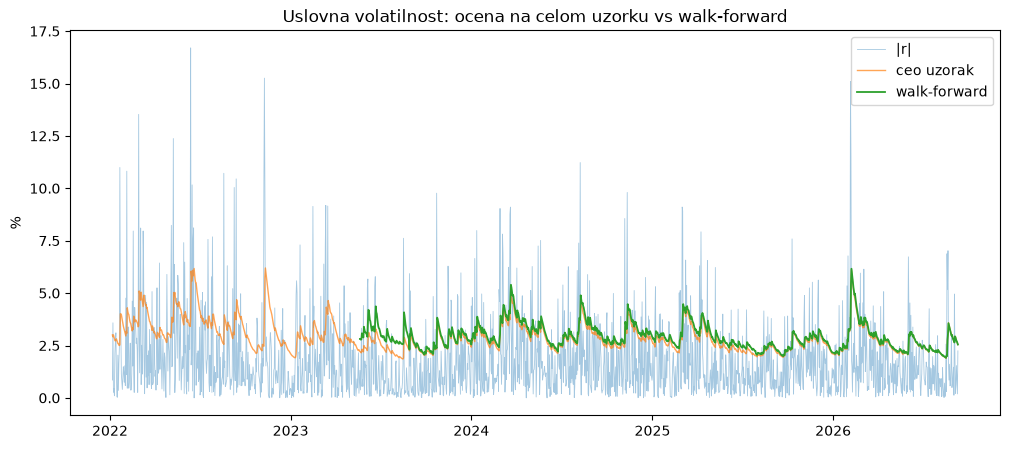

In [45]:
plt.figure(figsize=(12, 5))
plt.plot(df["date"], np.abs(r), lw=0.6, alpha=0.4, label="|r|")
plt.plot(df["date"], res_t.conditional_volatility, lw=1, alpha=0.7, label="ceo uzorak")
plt.plot(df["date"], arr, lw=1.3, label="walk-forward")
plt.ylabel("%")
plt.title("Uslovna volatilnost: ocena na celom uzorku vs walk-forward")
plt.legend()

Zelena linija je walk-forward procena, narandžasta ocena na celom uzorku. Obe prate isti obrazac: rastu posle velikih pomeraja i opadaju sporo, bez čistog praćenja pojedinačnih dana. To je i očekivano, pošto je $\hat\sigma_t$ tvrdnja o širini raspodele formirana pre nego što se dan odigrao, a ne prognoza samog prinosa.

Zelena linija ne postoji za prvih 500 dana, jer je to inicijalni trening set. Posledica je da turbulentni period iz 2022. ulazi u svaki prozor za ocenjivanje, ali nijednom ne ulazi u period testiranja. Walk-forward serija se kreće u rasponu od 1,99% do 6,16%, dok ocena na celom uzorku dostiže 7,5% u 2022. Za analizu tačnosti po režimima to znači manje varijacije režima nego što ceo uzorak sugeriše.

Zelena je kroz 2024. i 2025. blago iznad narandžaste. To je ista pojava koju pokazuje i dijagnostika: parametri ocenjeni na prozorima koji sadrže 2022. daju sistematski šire prognoze na mirnijem periodu.

Mali skokovi na granicama od 50 dana su ponovna ocenjivanja parametara, dakle očekivani su.